
# Neural Network Implementation from Scratch

**Course:** Generative AI Lab  
**Department:** CSE AIML  
**Class:** T.Y. Tech  
**Student Name:** Piyush Jangade  
**PRN Number:** 20240111040  
**Batch:** A1  
**Date of Submission:** 15-08-2026

## Objective

Implement a simple feedforward neural network from scratch in Python without using
built-in deep learning libraries. The implementation demonstrates the forward pass,
backpropagation, loss calculation, and training using gradient descent.

> The neural-network computations are implemented manually using NumPy. No
> TensorFlow, PyTorch, Keras, or other deep-learning frameworks are used.



## Part A — Problem Definition

### Dataset

The **Iris dataset** is used for this assignment. It contains measurements of iris
flowers belonging to three species:

- Setosa
- Versicolor
- Virginica

The four input features are:

1. Sepal length
2. Sepal width
3. Petal length
4. Petal width

### Task

This is a **multiclass classification** problem. The neural network predicts one of
the three Iris species from the four input measurements.

### Dataset Split

The dataset is divided into training and testing sets. Features are standardized
using statistics calculated from the training data only.


In [1]:

# Import only general-purpose numerical/data utilities.
# No deep-learning library is used.

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Iris dataset loaded from scikit-learn only as a dataset utility.
# The neural network itself is implemented completely from scratch.
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()

X = iris.data.astype(float)
y = iris.target.astype(int)

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("Classes:", iris.target_names)


Feature shape: (150, 4)
Target shape: (150,)
Classes: ['setosa' 'versicolor' 'virginica']



## Part B — Data Preprocessing

The neural network uses numerical feature values. Standardization is applied using:

**z = (x - mean) / standard deviation**

The mean and standard deviation are calculated only from the training set to avoid
data leakage.

The class labels are converted to one-hot vectors because the output layer contains
three neurons, one for each class.


In [2]:

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Standardize using training-set statistics
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

# One-hot encoding
def one_hot_encode(labels, num_classes):
    result = np.zeros((len(labels), num_classes))
    result[np.arange(len(labels)), labels] = 1
    return result

y_train_onehot = one_hot_encode(y_train, 3)
y_test_onehot = one_hot_encode(y_test, 3)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Input features:", X_train.shape[1])
print("Output classes:", y_train_onehot.shape[1])


Training samples: 120
Testing samples: 30
Input features: 4
Output classes: 3



## Part C — Neural Network Architecture

The network architecture is:

**Input Layer → Hidden Layer → Output Layer**

- Input layer: **4 neurons**
- Hidden layer: **8 neurons**
- Output layer: **3 neurons**
- Hidden-layer activation: **ReLU**
- Output-layer activation: **Softmax**
- Loss function: **Categorical Cross-Entropy**
- Optimizer: **Gradient Descent**
- Learning rate: **0.05**
- Number of epochs: **1000**

The softmax layer converts the final scores into probabilities whose sum is 1.


In [3]:

# Activation functions implemented from scratch

def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def softmax(z):
    # Subtracting max improves numerical stability.
    shifted = z - np.max(z, axis=1, keepdims=True)
    exp_values = np.exp(shifted)
    return exp_values / np.sum(exp_values, axis=1, keepdims=True)

def cross_entropy(y_true, y_pred):
    # Small epsilon prevents log(0).
    epsilon = 1e-12
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.mean(np.sum(y_true * np.log(y_pred), axis=1))



## Part D — Weight Initialization

Weights are initialized with small random values. Biases are initialized to zero.

For a layer:

**Z = XW + b**

where `W` represents weights and `b` represents biases.


In [4]:

# Network dimensions
input_size = 4
hidden_size = 8
output_size = 3

# Xavier-style initialization
W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2 / input_size)
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2 / hidden_size)
b2 = np.zeros((1, output_size))

print("W1 shape:", W1.shape)
print("b1 shape:", b1.shape)
print("W2 shape:", W2.shape)
print("b2 shape:", b2.shape)


W1 shape: (4, 8)
b1 shape: (1, 8)
W2 shape: (8, 3)
b2 shape: (1, 3)



## Part E — Forward Pass

During forward propagation:

1. The input is multiplied by the first layer's weights.
2. The hidden-layer bias is added.
3. ReLU is applied.
4. The hidden representation is passed to the output layer.
5. Softmax converts output scores into class probabilities.

Equations:

**Z1 = XW1 + b1**

**A1 = ReLU(Z1)**

**Z2 = A1W2 + b2**

**A2 = Softmax(Z2)**

The output `A2` contains the predicted probability for each class.


In [5]:

def forward_pass(X):
    # Hidden layer
    Z1 = X @ W1 + b1
    A1 = relu(Z1)

    # Output layer
    Z2 = A1 @ W2 + b2
    A2 = softmax(Z2)

    # Cache intermediate values for backpropagation
    cache = {
        "X": X,
        "Z1": Z1,
        "A1": A1,
        "Z2": Z2,
        "A2": A2
    }

    return A2, cache

# Test forward pass
predictions, cache = forward_pass(X_train)

print("Output shape:", predictions.shape)
print("First prediction probabilities:", predictions[0])
print("Probability sum:", predictions[0].sum())


Output shape: (120, 3)
First prediction probabilities: [0.33285188 0.33783405 0.32931407]
Probability sum: 1.0



## Part F — Backpropagation

Backpropagation calculates how much each parameter contributed to the prediction
error. These gradients are then used to update the weights and biases.

For softmax combined with cross-entropy:

**dZ2 = A2 - Y**

Then:

**dW2 = A1ᵀ dZ2 / m**

**db2 = sum(dZ2) / m**

The hidden-layer gradient is:

**dA1 = dZ2 W2ᵀ**

**dZ1 = dA1 × ReLU'(Z1)**

Then:

**dW1 = Xᵀ dZ1 / m**

**db1 = sum(dZ1) / m**

where `m` is the number of training examples.


In [6]:

def backward_pass(cache, y_true):
    global W1, b1, W2, b2

    X = cache["X"]
    Z1 = cache["Z1"]
    A1 = cache["A1"]
    A2 = cache["A2"]

    m = X.shape[0]

    # Output layer gradient
    dZ2 = A2 - y_true
    dW2 = (A1.T @ dZ2) / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m

    # Hidden layer gradient
    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = (X.T @ dZ1) / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    gradients = {
        "dW1": dW1,
        "db1": db1,
        "dW2": dW2,
        "db2": db2
    }

    return gradients



## Part G — Gradient Descent Training

Gradient descent updates each parameter in the direction that reduces the loss:

**parameter = parameter - learning_rate × gradient**

The complete training process repeatedly performs:

1. Forward pass
2. Loss calculation
3. Backpropagation
4. Weight and bias updates

The training loss and accuracy are stored for visualization.


In [7]:

learning_rate = 0.05
epochs = 1000

loss_history = []
accuracy_history = []

def accuracy(y_true_labels, y_pred_prob):
    predicted_labels = np.argmax(y_pred_prob, axis=1)
    return np.mean(predicted_labels == y_true_labels)

for epoch in range(epochs):
    # Forward pass
    y_pred, cache = forward_pass(X_train)

    # Loss
    loss = cross_entropy(y_train_onehot, y_pred)

    # Backpropagation
    gradients = backward_pass(cache, y_train_onehot)

    # Gradient descent updates
    W1 -= learning_rate * gradients["dW1"]
    b1 -= learning_rate * gradients["db1"]
    W2 -= learning_rate * gradients["dW2"]
    b2 -= learning_rate * gradients["db2"]

    # Training accuracy
    train_acc = accuracy(y_train, y_pred)

    loss_history.append(loss)
    accuracy_history.append(train_acc)

    if (epoch + 1) % 100 == 0:
        print(
            f"Epoch {epoch + 1:4d} | "
            f"Loss: {loss:.4f} | "
            f"Accuracy: {train_acc * 100:.2f}%"
        )


Epoch  100 | Loss: 0.3625 | Accuracy: 85.83%
Epoch  200 | Loss: 0.2434 | Accuracy: 88.33%
Epoch  300 | Loss: 0.1863 | Accuracy: 95.00%
Epoch  400 | Loss: 0.1490 | Accuracy: 95.83%
Epoch  500 | Loss: 0.1230 | Accuracy: 96.67%
Epoch  600 | Loss: 0.1014 | Accuracy: 96.67%
Epoch  700 | Loss: 0.0887 | Accuracy: 96.67%
Epoch  800 | Loss: 0.0804 | Accuracy: 96.67%
Epoch  900 | Loss: 0.0740 | Accuracy: 96.67%
Epoch 1000 | Loss: 0.0688 | Accuracy: 97.50%


## Part H — Training Loss Visualization

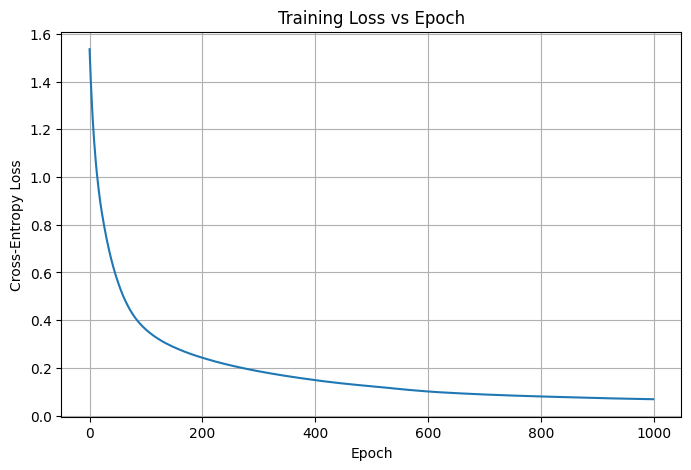

In [8]:

plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Training Loss vs Epoch")
plt.grid(True)
plt.show()


## Part I — Training Accuracy Visualization

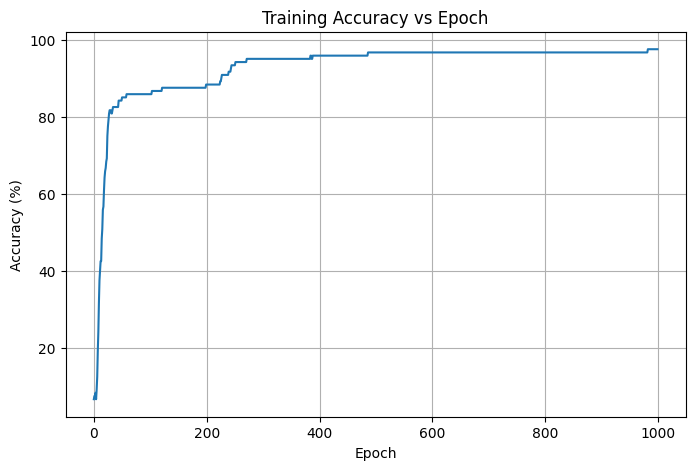

In [9]:

plt.figure(figsize=(8, 5))
plt.plot(np.array(accuracy_history) * 100)
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training Accuracy vs Epoch")
plt.grid(True)
plt.show()



## Part J — Model Testing

After training, the network is evaluated on the unseen test set. The test data is
processed using the training-set mean and standard deviation.


In [10]:

# Test set prediction
test_predictions, _ = forward_pass(X_test)

test_loss = cross_entropy(y_test_onehot, test_predictions)
test_accuracy = accuracy(y_test, test_predictions)

predicted_classes = np.argmax(test_predictions, axis=1)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

print("\nSample predictions:")
for i in range(min(10, len(X_test))):
    print(
        f"Actual: {iris.target_names[y_test[i]]:10s} | "
        f"Predicted: {iris.target_names[predicted_classes[i]]:10s} | "
        f"Probabilities: {np.round(test_predictions[i], 3)}"
    )


Test Loss: 0.1126
Test Accuracy: 93.33%

Sample predictions:
Actual: setosa     | Predicted: setosa     | Probabilities: [0.999 0.001 0.   ]
Actual: virginica  | Predicted: virginica  | Probabilities: [0.003 0.146 0.851]
Actual: versicolor | Predicted: versicolor | Probabilities: [0.037 0.962 0.001]
Actual: versicolor | Predicted: versicolor | Probabilities: [0.013 0.986 0.001]
Actual: setosa     | Predicted: setosa     | Probabilities: [0.999 0.001 0.   ]
Actual: versicolor | Predicted: versicolor | Probabilities: [0.042 0.728 0.23 ]
Actual: setosa     | Predicted: setosa     | Probabilities: [1. 0. 0.]
Actual: setosa     | Predicted: setosa     | Probabilities: [0.998 0.002 0.   ]
Actual: virginica  | Predicted: virginica  | Probabilities: [0.    0.014 0.986]
Actual: versicolor | Predicted: versicolor | Probabilities: [0.041 0.885 0.073]



## Part K — Confusion Matrix

A confusion matrix shows the number of correct and incorrect predictions for each
class. Rows represent actual classes and columns represent predicted classes.


Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


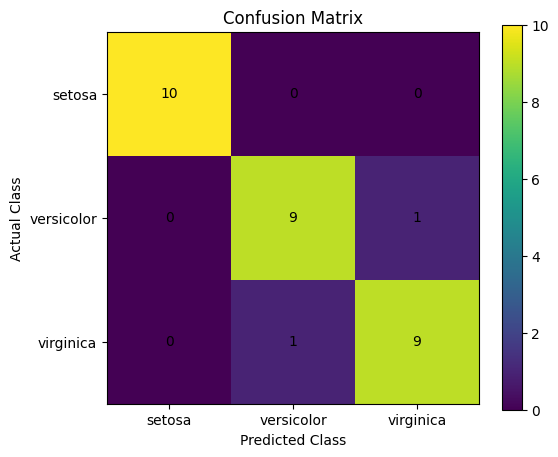

In [11]:

# Build confusion matrix manually
num_classes = 3
confusion_matrix = np.zeros((num_classes, num_classes), dtype=int)

for actual, predicted in zip(y_test, predicted_classes):
    confusion_matrix[actual, predicted] += 1

print("Confusion Matrix:")
print(confusion_matrix)

plt.figure(figsize=(6, 5))
plt.imshow(confusion_matrix)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.xticks(range(num_classes), iris.target_names)
plt.yticks(range(num_classes), iris.target_names)

for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, confusion_matrix[i, j], ha="center", va="center")

plt.colorbar()
plt.show()



## Part L — Results and Discussion

The feedforward neural network successfully learned the relationship between the
four Iris measurements and the three flower classes.

### Observations

- The training loss decreases as the number of epochs increases.
- Training accuracy improves during optimization.
- The trained model produces class probabilities using the softmax output layer.
- Test accuracy indicates how well the model generalizes to unseen data.
- The confusion matrix provides a class-wise view of the model's predictions.

The experiment demonstrates the complete neural-network learning pipeline without
using a built-in deep-learning framework.



## Part M — Key Concepts Demonstrated

| Component | Implementation |
|---|---|
| Input layer | 4 neurons |
| Hidden layer | 8 neurons |
| Hidden activation | ReLU |
| Output layer | 3 neurons |
| Output activation | Softmax |
| Loss | Categorical Cross-Entropy |
| Backpropagation | Manual gradient calculations |
| Optimizer | Batch Gradient Descent |
| Deep-learning library | Not used |
| Dataset | Iris |

### Conclusion

A simple feedforward neural network was implemented from scratch using NumPy.
Forward propagation was used to generate predictions, categorical cross-entropy was
used to measure the error, and backpropagation calculated gradients for updating
the model parameters. Gradient descent gradually minimized the training loss and
improved classification accuracy.



## Declaration

I, **Piyush Jangade**, confirm that the work submitted in this assignment is my own
and has been completed following academic integrity guidelines.

The code is uploaded on my GitHub repository account, and the repository link is
provided below.

**GitHub Repository Link:** ______________________________

**Signature:** Piyush Jangade



## Submission Checklist

- [x] Code file (Python Notebook)
- [x] Dataset or link to the dataset
- [x] Visualizations
- [x] Model performance metrics
- [ ] GitHub repository link
- [ ] Readme File

### Note

The GitHub repository link and PRN number should be filled in before submission.
